In [ ]:
import pandas as pd

customers = pd.read_csv("olist_customers_dataset.csv")
orders = pd.read_csv("olist_orders_dataset.csv")
payments = pd.read_csv("olist_order_payments_dataset.csv")

In [ ]:
customers.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [ ]:
orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [ ]:
payments.head()

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45


In [ ]:
customers.info()
orders.info()
payments.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4

In [ ]:
orders['order_purchase_timestamp'] = pd.to_datetime(orders['order_purchase_timestamp'])

In [ ]:
orders = orders[orders['order_status'] == 'delivered']

In [ ]:
df = orders.merge(customers, on="customer_id")
df = df.merge(payments, on="order_id")

In [ ]:
df.head()
df.shape

(100756, 16)

In [ ]:
customer_summary = df.groupby("customer_unique_id").agg({
    "order_id": "nunique",
    "payment_value": "sum",
    "order_purchase_timestamp": ["min", "max"]
}).reset_index()

In [ ]:
customer_summary.columns = [
    "customer",
    "total_orders",
    "total_spending",
    "first_purchase",
    "last_purchase"
]

# ANALSIS UTAMA

1. Repeat vs One-time

In [ ]:
customer_summary["customer_type"] = customer_summary["total_orders"].apply(
    lambda x: "Repeat" if x > 1 else "One-time"
)

customer_summary["customer_type"].value_counts(normalize=True) * 100

,proportion
customer_type,
One-time,96.999689
Repeat,3.000311


2. Total Revenue

In [ ]:
total_revenue = customer_summary["total_spending"].sum()
print(total_revenue)

15422461.769999998


3. Revenue by Type

In [ ]:
revenue_by_type = customer_summary.groupby("customer_type")["total_spending"].sum()
print(revenue_by_type)

customer_type
One-time    14558104.56
Repeat        864357.21
Name: total_spending, dtype: float64


# RFM Analysis

1. Recency

In [ ]:
import datetime as dt

today = customer_summary["last_purchase"].max()

customer_summary["recency"] = (today - customer_summary["last_purchase"]).dt.days

2. Frequency

In [ ]:
customer_summary["frequency"] = customer_summary["total_orders"]

3. Monetary

In [ ]:
customer_summary["monetary"] = customer_summary["total_spending"]

In [ ]:
#segmentasi customer
def segment_customer(row):
    if row["frequency"] > 1 and row["monetary"] > 500:
        return "High Value Repeat"
    elif row["frequency"] > 1:
        return "Repeat"
    elif row["monetary"] > 500:
        return "High Value One-time"
    else:
        return "Low Value"

customer_summary["segment"] = customer_summary.apply(segment_customer, axis=1)

In [ ]:
customer_summary["segment"].value_counts()

,count
segment,
Low Value,86659
High Value One-time,3897
Repeat,2433
High Value Repeat,368


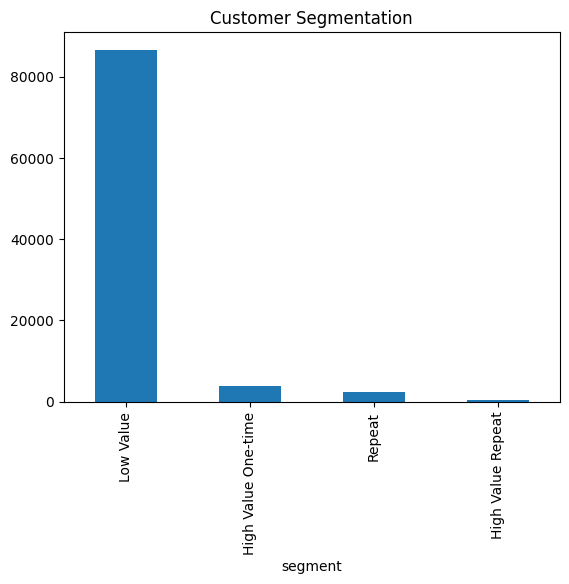

In [ ]:
import matplotlib.pyplot as plt

customer_summary["segment"].value_counts().plot(kind="bar")
plt.title("Customer Segmentation")
plt.show()

# analisis tambahan

1. Revenue by Segment

segement mana yang paling banyak menyumbang revenue?

In [ ]:
segment_revenue = customer_summary.groupby("segment")["total_spending"].sum().sort_values(ascending=False)
segment_revenue

,total_spending
segment,
Low Value,10940844.22
High Value One-time,3617260.34
Repeat,543979.26
High Value Repeat,320377.95


In [ ]:
segment_revenue_pct = segment_revenue / segment_revenue.sum() * 100
segment_revenue_pct

,total_spending
segment,
Low Value,70.940972
High Value One-time,23.454494
Repeat,3.527188
High Value Repeat,2.077346


2. Average Spending by Segment

apakah high value repeat punya rata rata spending tinggi?

In [ ]:
avg_spending_segment = customer_summary.groupby("segment")["total_spending"].mean().sort_values(ascending=False)
avg_spending_segment

,total_spending
segment,
High Value One-time,928.216664
High Value Repeat,870.592255
Repeat,223.583748
Low Value,126.251679


3. Visualisasi

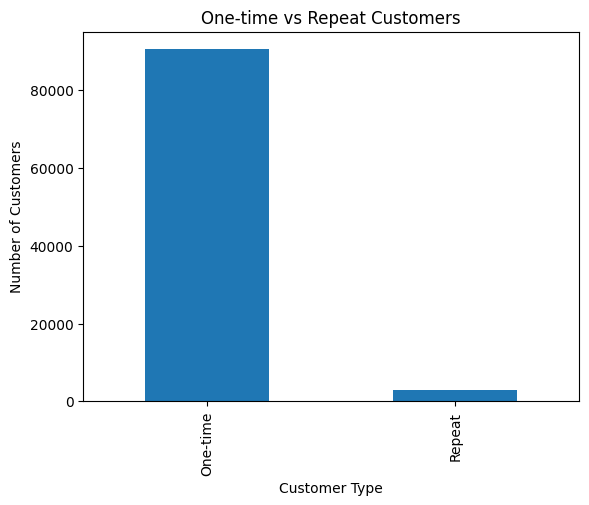

In [ ]:
import matplotlib.pyplot as plt

customer_summary["customer_type"].value_counts().plot(kind="bar")
plt.title("One-time vs Repeat Customers")
plt.xlabel("Customer Type")
plt.ylabel("Number of Customers")
plt.show()

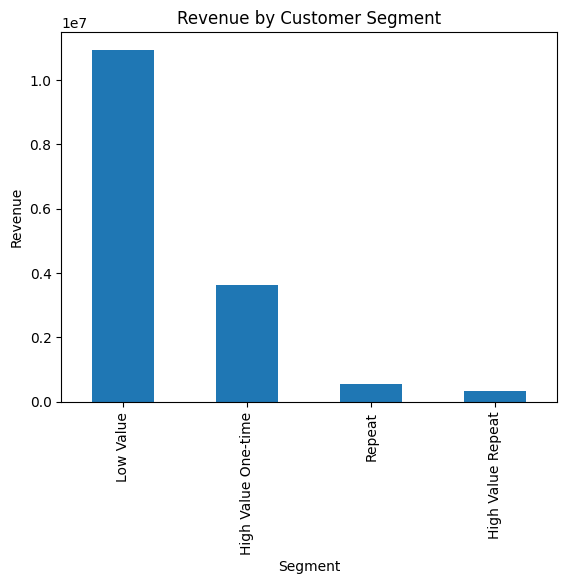

In [ ]:
segment_revenue.plot(kind="bar")
plt.title("Revenue by Customer Segment")
plt.xlabel("Segment")
plt.ylabel("Revenue")
plt.show()

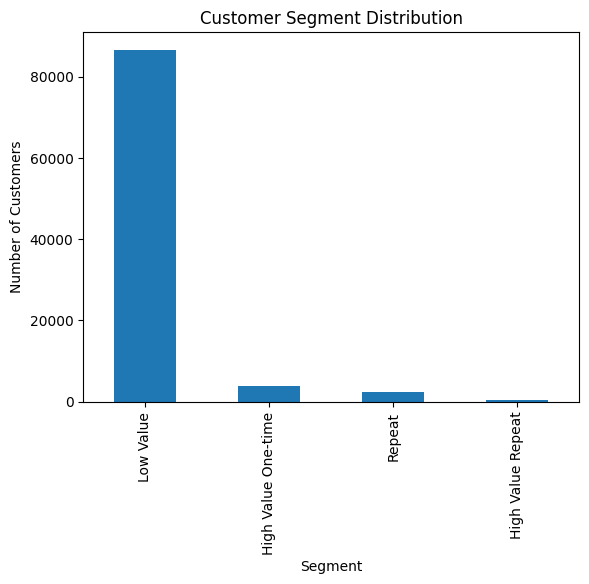

In [ ]:
customer_summary["segment"].value_counts().plot(kind="bar")
plt.title("Customer Segment Distribution")
plt.xlabel("Segment")
plt.ylabel("Number of Customers")
plt.show()